# Chapter 3 — Statistical Experiments and Significance Testing

This chapter introduces experimental design and statistical significance
testing.

The main topics are:

- A/B testing
- Hypothesis testing
- Permutation tests
- Statistical significance and p-values
- t-tests
- Multiple testing
- Degrees of freedom
- ANOVA
- Chi-square tests
- Multi-arm bandits
- Statistical power and sample size

The central idea is to determine whether an observed difference between
groups can reasonably be attributed to random variation or whether the
evidence is inconsistent with the assumed null model.

## 1. A/B Testing

An A/B test compares two treatments or alternatives.

For example, a website might randomly assign visitors to:

- Page A
- Page B

and compare a response such as session time or conversion rate.

Random assignment helps separate the treatment effect from other factors.

A control group is useful because it provides a baseline representing
what would happen without the treatment.

Although A/B testing usually compares two alternatives, experiments can
also compare three or more treatments.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

session_times = pd.read_csv('../data/four_sessions.csv')

group_summary = (
    session_times
    .groupby('Page')['Time']
    .agg(['count', 'mean', 'std'])
    .rename(columns={
        'count': 'Observations',
        'mean': 'Mean Session Time',
        'std': 'Standard Deviation'
    })
)

display(group_summary.round(2))

,Observations,Mean Session Time,Standard Deviation
Page,,,
Page 1,5,172.8,14.75
Page 2,5,182.6,5.68
Page 3,5,175.6,10.99
Page 4,5,164.6,5.81


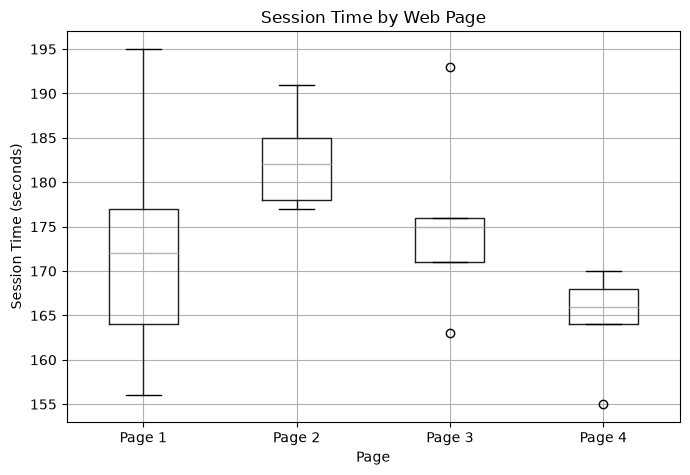

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

session_times.boxplot(
    by='Page',
    column='Time',
    ax=ax
)

ax.set_title('Session Time by Web Page')
ax.set_xlabel('Page')
ax.set_ylabel('Session Time (seconds)')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 2. Hypothesis Tests

A hypothesis test starts with a null hypothesis.

### Null hypothesis

The null hypothesis represents the assumption that there is no special
effect and that the observed difference can be explained by random
chance.

### Alternative hypothesis

The alternative hypothesis represents the effect or difference that we
are investigating.

A test can be:

- One-way (one-tailed): interested in an effect in one direction.
- Two-way (two-tailed): interested in an effect in either direction.

The test compares the observed result with what would be expected under
the null hypothesis.

## 3. Resampling and Permutation Tests

Permutation testing creates a reference distribution by repeatedly
reallocating observed observations between groups.

For an A/B experiment:

1. Combine the observations from both groups.
2. Randomly reassign observations to the groups.
3. Calculate the difference in the chosen statistic.
4. Repeat many times.
5. Compare the observed difference with the resulting distribution.

Unlike bootstrap resampling, permutation testing is primarily used for
testing hypotheses rather than estimating the variability of an estimate.

## 4. Statistical Significance and p-Values

A p-value measures how frequently a result at least as extreme as the
observed result would occur under the null model.

A small p-value indicates that the observed result is relatively unusual
under the null hypothesis.

The p-value does NOT represent:

- the probability that the null hypothesis is true
- the probability that the result occurred by chance
- the size or practical importance of an effect

### Alpha

Alpha is a threshold used to define a significance level, commonly 0.05.

If the p-value is below the selected alpha level, the result is described
as statistically significant under that testing procedure.

## 5. Type I and Type II Errors

Hypothesis testing can produce two important types of errors.

### Type I error

Rejecting the null hypothesis when it is actually true.

This is a false positive.

### Type II error

Failing to reject the null hypothesis when the alternative is actually
true.

This is a false negative.

The choice of alpha controls the tolerated probability of a Type I error
under the assumptions of the test.

## 6. t-Tests

A t-test compares means using the t-distribution.

It is commonly used when comparing the means of two groups with numeric
data.

The t-statistic standardizes the difference between the observed group
means.

In practice, Python provides the test through scipy.stats.

## 7. Multiple Testing

Performing many statistical tests increases the probability of obtaining
at least one statistically significant result purely by chance.

For example, if 20 independent tests are performed using alpha = 0.05,
the probability of at least one false positive can become substantial.

This phenomenon is called alpha inflation.

Therefore, when many hypotheses are tested, the number of tests needs to
be considered when interpreting statistical significance.

In [8]:
# Probability of at least one false positive across
# multiple independent tests at alpha = 0.05.

alpha = 0.05
number_of_tests = np.arange(1, 21)

false_positive_probability = (
    1 - (1 - alpha) ** number_of_tests
)

multiple_testing = pd.DataFrame({
    'Number of Tests': number_of_tests,
    'Probability of ≥1 False Positive':
        false_positive_probability
})

display(
    multiple_testing.iloc[[0, 4, 9, 19]]
    .style.format({
        'Probability of ≥1 False Positive': '{:.1%}'
    })
)

,Number of Tests,Probability of ≥1 False Positive
0,1,5.0%
4,5,22.6%
9,10,40.1%
19,20,64.2%


## 8. Degrees of Freedom

Degrees of freedom describe how many independent pieces of information
are available when estimating a statistic.

They appear throughout statistical procedures, including:

- t-tests
- Chi-square tests
- ANOVA
- F-tests

The appropriate degrees of freedom depend on the structure of the data
and the statistic being calculated.

## 9. ANOVA

Analysis of Variance (ANOVA) extends the comparison of means to more than
two groups.

Instead of performing many separate pairwise tests, ANOVA evaluates
whether the variation among group means is large relative to the
variation within groups.

The F-statistic is:

F = variation among groups / variation within groups

A larger F-statistic indicates that the differences among group means are
large relative to the residual variation.

In [9]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

four_sessions = pd.DataFrame({
    'Page': (
        ['Page 1'] * 5 +
        ['Page 2'] * 5 +
        ['Page 3'] * 5 +
        ['Page 4'] * 5
    ),
    'Time': [
        164, 172, 177, 156, 195,
        178, 191, 182, 185, 177,
        175, 193, 171, 163, 176,
        155, 166, 164, 170, 168
    ]
})

group_means = (
    four_sessions
    .groupby('Page')['Time']
    .mean()
    .rename('Mean Session Time')
)

display(group_means.to_frame().round(2))

,Mean Session Time
Page,
Page 1,172.8
Page 2,182.6
Page 3,175.6
Page 4,164.6


In [11]:
model = smf.ols(
    'Time ~ Page',
    data=four_sessions
).fit()

anova_table = sm.stats.anova_lm(model)

display(anova_table.round(4))

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.1333,2.7398,0.0776
Residual,16.0,1618.4,101.1500,NaN,NaN


## 10. Two-Way ANOVA

One-way ANOVA considers one factor.

Two-way ANOVA considers two factors and can examine:

- The effect of the first factor
- The effect of the second factor
- The interaction between the two factors

An interaction occurs when the effect of one factor depends on the level
of another factor.

## 11. Chi-Square Test

The chi-square test is commonly used for categorical count data.

It compares observed counts with the counts expected under a null model.

The chi-square statistic increases as the observed counts depart from
the expected counts.

For a contingency table, the test can be used to examine whether
categorical variables are associated.

In [17]:
from scipy.stats import chi2_contingency

import numpy as np
# Example contingency table:
# rows = treatment groups
# columns = outcome categories

observed = np.array([
    [34, 966],
    [28, 972],
    [40, 960]
])

chi2_stat, p_value, degrees_freedom, expected = (
    chi2_contingency(observed)
)

chi_square_summary = pd.Series({
    'Chi-square statistic': chi2_stat,
    'Degrees of freedom': degrees_freedom,
    'p-value': p_value
})

display(
    chi_square_summary
    .to_frame('Value')
    .style.format('{:.4f}')
)

,Value
Chi-square statistic,2.1922
Degrees of freedom,2.0000
p-value,0.3342


## 12. Fisher's Exact Test

Fisher's exact test provides an exact test for a 2 × 2 contingency table.

It is particularly useful when expected counts are very small, where the
chi-square approximation may be less reliable.

In [13]:
from scipy.stats import fisher_exact

table_2x2 = np.array([
    [8, 2],
    [3, 7]
])

odds_ratio, fisher_p = fisher_exact(table_2x2)

fisher_summary = pd.Series({
    'Odds ratio': odds_ratio,
    'p-value': fisher_p
})

display(
    fisher_summary
    .to_frame('Value')
    .style.format('{:.4f}')
)

,Value
Odds ratio,9.3333
p-value,0.0698


## 13. Multi-Arm Bandit Algorithm

A traditional A/B test generally collects data according to a fixed
experimental design and analyzes the results afterward.

A multi-arm bandit instead allows the experiment to adapt as results
arrive.

Each treatment is considered an "arm".

The algorithm faces a trade-off between:

- Exploration: trying treatments to learn more about them.
- Exploitation: allocating more trials to treatments that currently
  appear successful.

This approach can be useful for continuously optimizing online
experiments.

In [14]:
# Simple illustration of the exploration/exploitation idea.

results = pd.DataFrame({
    'Arm': ['A', 'B', 'C'],
    'Wins': [10, 2, 4],
    'Trials': [50, 50, 50]
})

results['Estimated Win Rate'] = (
    results['Wins'] / results['Trials']
)

display(
    results.style.format({
        'Estimated Win Rate': '{:.1%}'
    })
)

,Arm,Wins,Trials,Estimated Win Rate
0,A,10,50,20.0%
1,B,2,50,4.0%
2,C,4,50,8.0%


## 14. Power and Sample Size

Statistical power is the probability of detecting an effect of a specified
size when that effect actually exists.

Four quantities are closely related:

- Sample size
- Effect size
- Significance level (alpha)
- Statistical power

If three are specified, the fourth can be calculated.

A larger desired effect is generally easier to detect, while detecting a
small effect generally requires more observations.

In [15]:
from statsmodels.stats.power import TTestIndPower

# Estimate the sample size required to detect
# a specified standardized effect.

analysis = TTestIndPower()

sample_size = analysis.solve_power(
    effect_size=0.5,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

power_summary = pd.Series({
    'Effect size': 0.5,
    'Alpha': 0.05,
    'Desired power': 0.80,
    'Required sample size per group': sample_size
})

display(
    power_summary
    .to_frame('Value')
    .style.format({
        'Effect size': '{:.2f}',
        'Alpha': '{:.2f}',
        'Desired power': '{:.0%}',
        'Required sample size per group': '{:.1f}'
    })
)

,Value
Effect size,0.500000
Alpha,0.050000
Desired power,0.800000
Required sample size per group,63.765611


# Chapter 3 Summary

This chapter examined how experiments can be designed and analyzed to
distinguish meaningful effects from random variation.

The major concepts were:

- A/B testing and experimental controls
- Null and alternative hypotheses
- One-way and two-way hypothesis tests
- Permutation testing
- p-values and statistical significance
- Type I and Type II errors
- t-tests
- Multiple testing and alpha inflation
- Degrees of freedom
- ANOVA and the F-statistic
- Chi-square and Fisher's exact tests
- Multi-arm bandits
- Statistical power and sample size

A central theme is that an observed difference does not automatically
demonstrate an effect. The experimental design and the assumed chance
model determine how the evidence should be evaluated.

For data science, resampling methods provide a flexible way to construct
reference distributions directly from observed data, while traditional
tests such as t-tests, ANOVA, and chi-square tests provide established
statistical procedures for common situations.